In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, gaussian_kde
from scipy.optimize import curve_fit
from scikit_posthocs import posthoc_dunn

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score)

def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def washburn_radius(L, gamma, t, phi, eta):
    L = np.asarray(L, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    denom = gamma * t * np.cos(phi)
    return (2 * eta * L**2) / denom

def washburn_length(r, gamma, t, phi, eta):
    r = np.asarray(r, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    inside = (gamma * r * t * np.cos(phi)) / (2 * eta)
    return np.sqrt(inside)

def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def inspect_dataframe(name, df):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nHead:")
    print(df.head())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSummary statistics:")
    print(df.describe(include="all"))


dunking-data.csv
Shape: (3000, 6)

Columns: ['gamma', 'phi', 'eta', 'L', 't', 'biscuit']

Head:
      gamma       phi       eta         L          t    biscuit
0  0.073897  1.333006  0.000999  0.011196  19.362214  Digestive
1  0.080946  1.476758  0.001012  0.005894  11.852589  Digestive
2  0.087408  1.477141  0.000984  0.009249  24.793669  Digestive
3  0.070793  1.502001  0.001002  0.003774  16.292780     Hobnob
4  0.058917  1.548274  0.001004  0.002291  13.662271     Hobnob

Missing values:
gamma      0
phi        0
eta        0
L          0
t          0
biscuit    0
dtype: int64

Duplicate rows: 0

Summary statistics:
              gamma          phi          eta            L            t  \
count   3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN

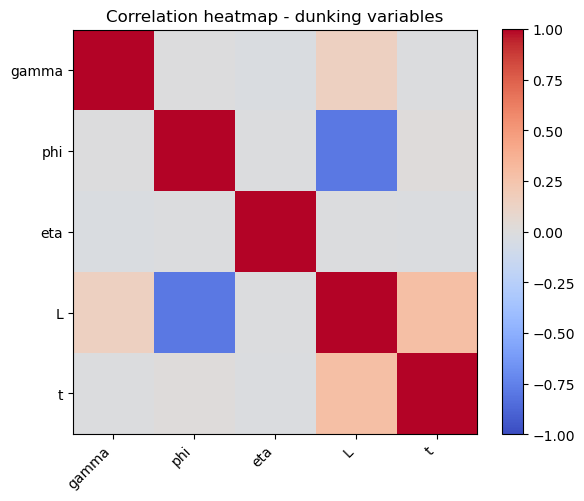

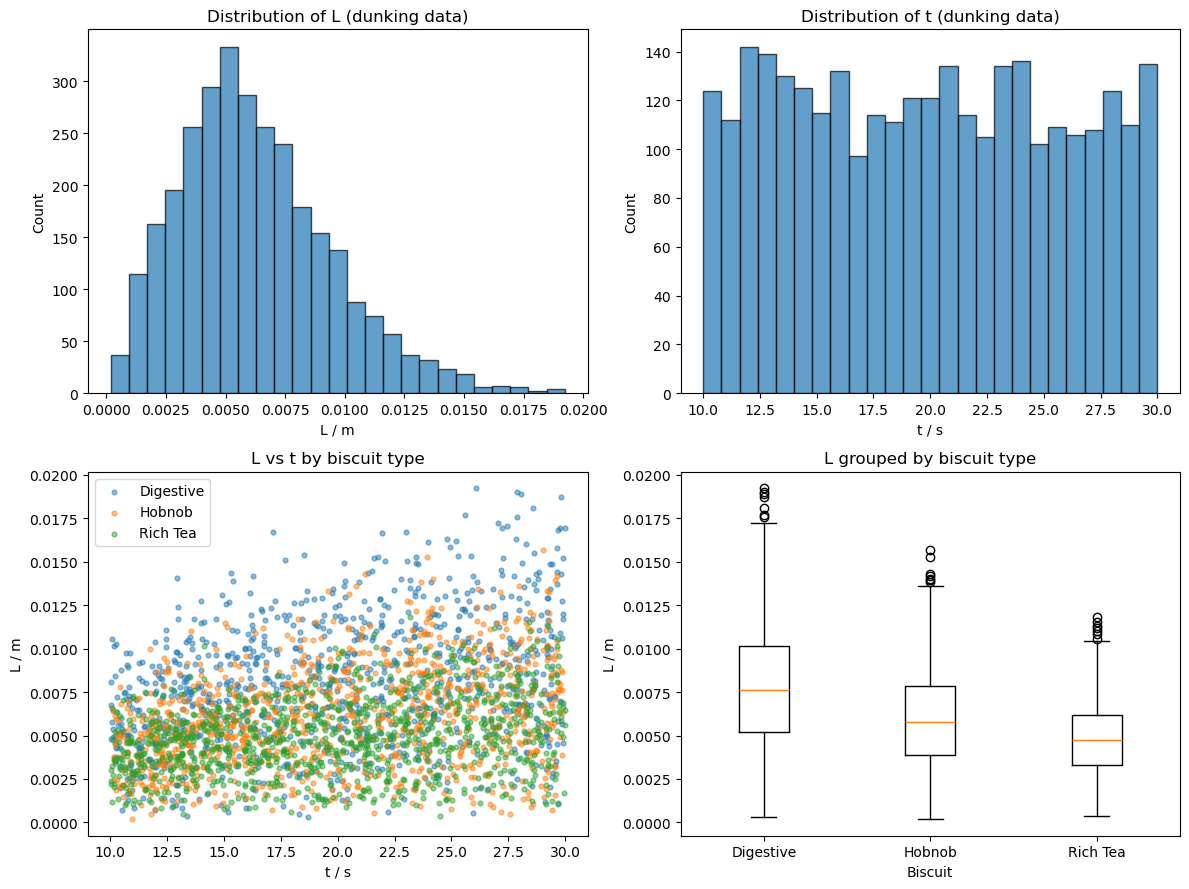

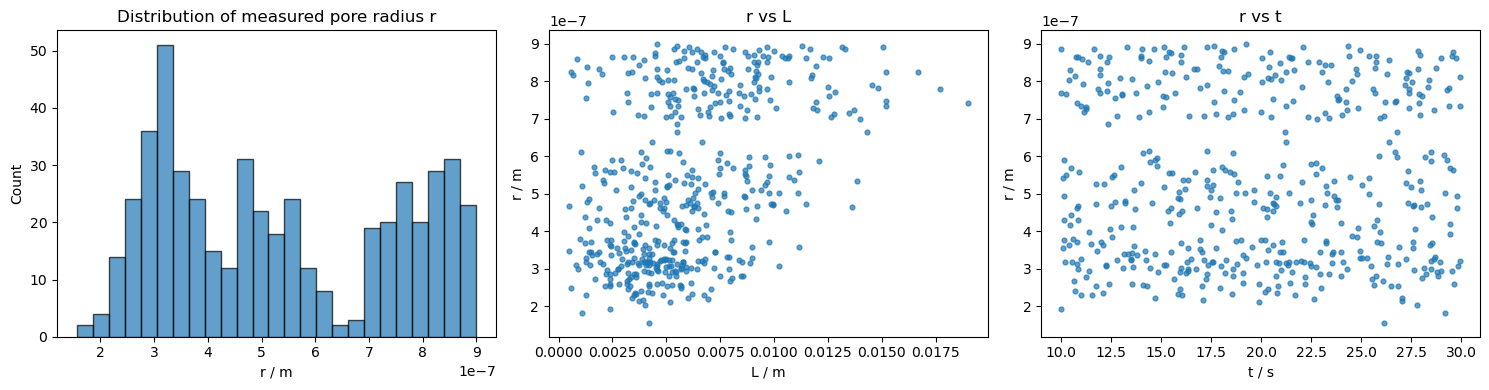

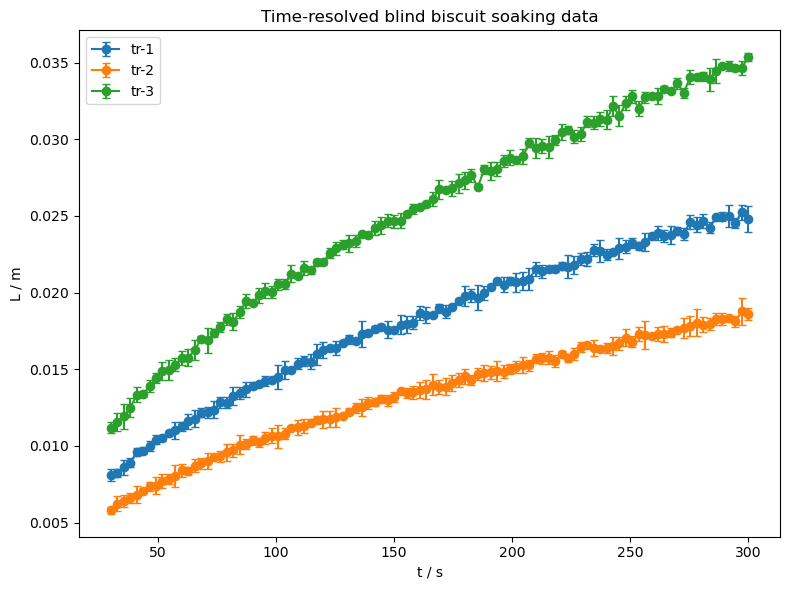

In [4]:
dunk = pd.read_csv("dunking-data.csv")
micro = pd.read_csv("microscopy-data.csv")
tr1 = pd.read_csv("tr-1.csv")
tr2 = pd.read_csv("tr-2.csv")
tr3 = pd.read_csv("tr-3.csv")

blind_samples = {"tr-1": tr1.copy(), "tr-2": tr2.copy(), "tr-3": tr3.copy()}

inspect_dataframe("dunking-data.csv", dunk)
inspect_dataframe("microscopy-data.csv", micro)
inspect_dataframe("tr-1.csv", tr1)
inspect_dataframe("tr-2.csv", tr2)
inspect_dataframe("tr-3.csv", tr3)

print("\nBiscuit class counts:")
print(dunk["biscuit"].value_counts())

dunk["abs_cos_phi"] = np.abs(np.cos(dunk["phi"]))
micro["abs_cos_phi"] = np.abs(np.cos(micro["phi"]))

print("\nPotentially inaccurate Washburn inversions")
print("dunk rows with |cos(phi)| < 0.001:", int((dunk["abs_cos_phi"] < 0.001).sum()))
print("micro rows with |cos(phi)| < 0.001:", int((micro["abs_cos_phi"] < 0.001).sum()))

corr_cols = ["gamma", "phi", "eta", "L", "t"] #correlation heatmap
corr = dunk[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation heatmap - dunking variables")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9)) #distribution and scatter plots 

axes[0, 0].hist(dunk["L"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of L (dunking data)")
axes[0, 0].set_xlabel("L / m")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(dunk["t"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Distribution of t (dunking data)")
axes[0, 1].set_xlabel("t / s")
axes[0, 1].set_ylabel("Count")

for biscuit in dunk["biscuit"].unique():
    sub = dunk[dunk["biscuit"] == biscuit]
    axes[1, 0].scatter(sub["t"], sub["L"], alpha=0.5, s=12, label=biscuit)
axes[1, 0].set_title("L vs t by biscuit type")
axes[1, 0].set_xlabel("t / s")
axes[1, 0].set_ylabel("L / m")
axes[1, 0].legend()

biscuit_order = sorted(dunk["biscuit"].unique())
box_data = [dunk.loc[dunk["biscuit"] == b, "L"] for b in biscuit_order]
axes[1, 1].boxplot(box_data, tick_labels=biscuit_order)
axes[1, 1].set_title("L grouped by biscuit type")
axes[1, 1].set_xlabel("Biscuit")
axes[1, 1].set_ylabel("L / m")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #micro scatter plots
axes[0].hist(micro["r"], bins=25, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of measured pore radius r")
axes[0].set_xlabel("r / m")
axes[0].set_ylabel("Count")
axes[1].scatter(micro["L"], micro["r"], alpha=0.7, s=12)
axes[1].set_title("r vs L")
axes[1].set_xlabel("L / m")
axes[1].set_ylabel("r / m")
axes[2].scatter(micro["t"], micro["r"], alpha=0.7, s=12)
axes[2].set_title("r vs t")
axes[2].set_xlabel("t / s")
axes[2].set_ylabel("r / m")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6)) #blind time data
for name, df in blind_samples.items():
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o-", capsize=3, label=name)
ax.set_title("Time-resolved blind biscuit soaking data")
ax.set_xlabel("t / s")
ax.set_ylabel("L / m")
ax.legend()
plt.tight_layout()
plt.show()